# Análisis de rentabilidad RappiPlus

En este notebook se realizará el análisis por medio de los datasets ya limpiados previamente.

## Importación de librerías

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Importación de datasets

In [119]:
orders = pd.read_csv(r'../data/rappiplus_orders_clean.csv')
marketing = pd.read_csv(r'../data/rappiplus_marketing_clean.csv')
catalog = pd.read_csv(r'../data/rappiplus_catalog_clean.csv')

## Análisis inicial

### Vista previa de los datos

#### Ordenes

In [120]:
orders.head(3)

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.00,332.69,0.00,665.38
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.00,176.86,5.00,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.00,102.99,10.00,195.98


In [121]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 24920 entries, 0 to 24919
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           24920 non-null  str    
 1   id_usuario          24920 non-null  str    
 2   fecha_hora_pedido   24920 non-null  str    
 3   pais                24920 non-null  str    
 4   dispositivo         24920 non-null  str    
 5   fuente_referencia   24920 non-null  str    
 6   nombre_producto     24920 non-null  str    
 7   categoria_producto  24920 non-null  str    
 8   cantidad            24920 non-null  float64
 9   precio_unitario     24920 non-null  float64
 10  monto_descuento     24920 non-null  float64
 11  monto_total         24920 non-null  float64
dtypes: float64(4), str(8)
memory usage: 2.3 MB


In [122]:
orders['fecha_hora_pedido'] = pd.to_datetime(orders['fecha_hora_pedido'])

#### Marketing

In [123]:
marketing.head(3)

,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,"2,446.25"
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,"2,704.34"
2,2025-01-01,Mexico,social_Mexico,social,"2,045.01"


In [124]:
marketing.info()

<class 'pandas.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   str    
 1   pais        1620 non-null   str    
 2   id_campaña  1620 non-null   str    
 3   canal       1620 non-null   str    
 4   gasto       1620 non-null   float64
dtypes: float64(1), str(4)
memory usage: 63.4 KB


In [125]:
marketing['fecha'] = pd.to_datetime(marketing['fecha'])

#### Catálogo

In [126]:
catalog.head(3)

,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC


In [127]:
catalog.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      str    
 1   categoria_producto  7 non-null      str    
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      str    
dtypes: float64(1), str(3)
memory usage: 356.0 bytes


### Análisis de rentabilidad

#### Preparación de dataset

Para obtener información clave para responder las preguntas objetivo del análsis, se unirán los datasets con las columnas necesarias.

In [128]:
# Agregación de columnas "costo unitario" y "proveedor" con la tabla de pedidos
ventas = orders.merge(
    catalog[['nombre_producto', 'costo_unitario', 'proveedor']],
    on = 'nombre_producto',
    how = 'left'
)

In [129]:
# Calculo de columna "Costo total"
ventas['costo_total'] = ventas['costo_unitario']*ventas['cantidad']

In [130]:
ventas.info()

<class 'pandas.DataFrame'>
RangeIndex: 24920 entries, 0 to 24919
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           24920 non-null  str           
 1   id_usuario          24920 non-null  str           
 2   fecha_hora_pedido   24920 non-null  datetime64[us]
 3   pais                24920 non-null  str           
 4   dispositivo         24920 non-null  str           
 5   fuente_referencia   24920 non-null  str           
 6   nombre_producto     24920 non-null  str           
 7   categoria_producto  24920 non-null  str           
 8   cantidad            24920 non-null  float64       
 9   precio_unitario     24920 non-null  float64       
 10  monto_descuento     24920 non-null  float64       
 11  monto_total         24920 non-null  float64       
 12  costo_unitario      24920 non-null  float64       
 13  proveedor           24920 non-null  str           
 14  c

In [131]:
# Reorganización de columnas
ventas = ventas[['id_pedido', 'fecha_hora_pedido', 'id_usuario', 'pais', 
                 'dispositivo', 'fuente_referencia', 'nombre_producto', 'categoria_producto',
                 'proveedor', 'cantidad', 'costo_unitario', 'precio_unitario',
                 'monto_total', 'costo_total', 'monto_descuento']]

In [132]:
ventas.head(2)

,id_pedido,fecha_hora_pedido,id_usuario,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,proveedor,cantidad,costo_unitario,precio_unitario,monto_total,costo_total,monto_descuento
0,order_0,2025-05-22,user_6993,Argentina,desktop,organic,Jacket-Winter-M,Moda,Mcmillan-Rhodes,2.00,189.31,332.69,665.38,378.62,0.00
1,order_1,2025-06-15,user_1329,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,Bowers LLC,1.00,25.21,176.86,171.86,25.21,5.00


#### Rentabilidad

In [133]:
# Calculo de ventas totales
ing_total = ventas['monto_total'].sum()

# Calculo de costos totales
costo_total = ventas['costo_total'].sum()
costo_marketing_total = marketing['gasto'].sum()
dsctos_total = ventas['monto_descuento'].sum()

# Calculo de rentabilidad
rentabilidad = ing_total - costo_total - costo_marketing_total
rentabilidad_pct = rentabilidad / ing_total * 100

In [134]:
print(f'Ingresos totales: ${ing_total:,.2f}')
print()
print(f'Costos totales: ${costo_total:,.2f}')
print(f'Costo total de marketing: ${costo_marketing_total:,.2f}')
print(f'Descuentos totales: ${dsctos_total:,.2f}')
print()
print(f'Rentabilidad: ${rentabilidad:,.2f}')
print(f'Rentabilidad en %: {rentabilidad_pct:,.2f}%')


Ingresos totales: $9,616,878.36

Costos totales: $3,834,533.21
Costo total de marketing: $2,871,843.53
Descuentos totales: $112,215.00

Rentabilidad: $2,910,501.62
Rentabilidad en %: 30.26%


In [135]:
# ingresos y costos por país
resumen_ventas = ventas.groupby('pais').agg(
    ingresos_totales = ('monto_total', 'sum'),
    costos_totales = ('costo_total', 'sum'),
    descuentos_totales = ('monto_descuento', 'sum')
).reset_index()

# Costos de marketing por país
resumen_marketing = marketing.groupby('pais').agg(
    costo_marketing = ('gasto', 'sum')
).reset_index()

# Unión de resumenes
resumen_final = resumen_ventas.merge(resumen_marketing, on = 'pais', how = 'left').fillna(0)

In [136]:
# Calculo de rentabilidad por pais
resumen_final['rentabilidad'] = resumen_final['ingresos_totales']-resumen_final['costos_totales']-resumen_final['costo_marketing']
resumen_final['rentabilidad_pct'] = (resumen_final['rentabilidad'] / resumen_final['ingresos_totales'])*100

In [137]:
# agregación de formato moneda y pct
for index, row in resumen_final.iterrows():
    print(f"--- {row['pais']} ---")
    print(f"Ingresos Totales:      ${row['ingresos_totales']:,.2f}")
    print(f"Costos Totales (COGS): ${row['costos_totales']:,.2f}")
    print(f"Descuentos Totales:    ${row['descuentos_totales']:,.2f}")
    print(f"Costo Mkt Total:       ${row['costo_marketing']:,.2f}")
    print(f"Rentabilidad ($):      ${row['rentabilidad']:,.2f}")
    print(f"Rentabilidad (%):      {row['rentabilidad_pct']:.2f}%\n")

--- Argentina ---
Ingresos Totales:      $3,122,690.14
Costos Totales (COGS): $1,237,715.30
Descuentos Totales:    $35,360.00
Costo Mkt Total:       $947,694.60
Rentabilidad ($):      $937,280.24
Rentabilidad (%):      30.02%

--- Colombia ---
Ingresos Totales:      $3,171,392.07
Costos Totales (COGS): $1,271,752.86
Descuentos Totales:    $37,150.00
Costo Mkt Total:       $935,653.42
Rentabilidad ($):      $963,985.79
Rentabilidad (%):      30.40%

--- Desconocido ---
Ingresos Totales:      $113,135.41
Costos Totales (COGS): $43,760.34
Descuentos Totales:    $1,345.00
Costo Mkt Total:       $0.00
Rentabilidad ($):      $69,375.07
Rentabilidad (%):      61.32%

--- Mexico ---
Ingresos Totales:      $3,209,660.74
Costos Totales (COGS): $1,281,304.71
Descuentos Totales:    $38,360.00
Costo Mkt Total:       $988,495.51
Rentabilidad ($):      $939,860.52
Rentabilidad (%):      29.28%



**Argentina, Colombia y México** tienen los indicadores muy similares, con margen del 30%, ingresos de $3 millones, costos de alrededor de $1.25 millones, gastos de marketing de alrededor de $950 mil y descuentos otorgados totales de $35 mil.

Sin embargo, recordando que durante la limpieza contabamos con 300 registros sin ubicación, podemos ver que el margen se dispara al 60% con ingresos totales mínimos ($113,135.50), y esto se debe a que no tenemos inversiones de marketing identificados en estos registros, por lo que la rentabilidad no es comparable con los paises existentes en la lista.

##### Visualizaciones

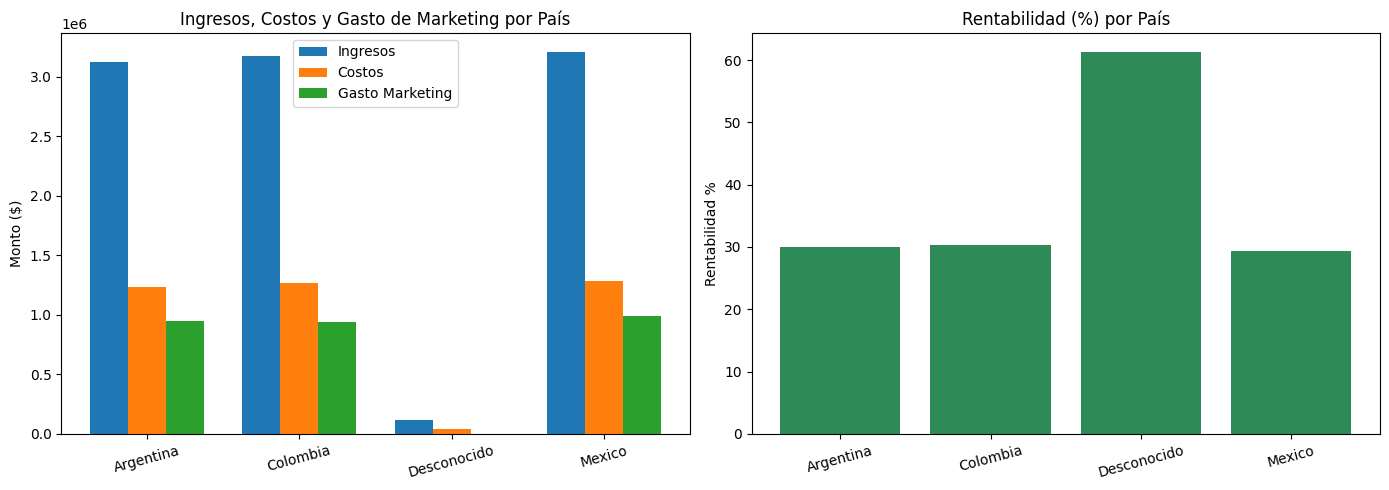

In [138]:
# Defino un conjunto de gráficos
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Definición de variables
paises = resumen_final['pais'] # Categoría de columnas
x = np.arange(len(paises)) # Posiciones numéricas en el eje X, una por país
width = 0.25 # Ancho de columnas

# Configuración manual de propiedades de columnas agrupadas
axes[0].bar(x - width, resumen_final['ingresos_totales'], width, label='Ingresos')
axes[0].bar(x, resumen_final['costos_totales'], width, label='Costos')
axes[0].bar(x + width, resumen_final['costo_marketing'], width, label='Gasto Marketing')

# Configuración de etiquetas y propiedades estéticas
axes[0].set_xticks(x)
axes[0].set_xticklabels(paises, rotation=15)
axes[0].set_title('Ingresos, Costos y Gasto de Marketing por País')
axes[0].set_ylabel('Monto ($)')
axes[0].legend()

axes[1].bar(paises, resumen_final['rentabilidad_pct'], color='seagreen')
axes[1].set_title('Rentabilidad (%) por País')
axes[1].set_ylabel('Rentabilidad %')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

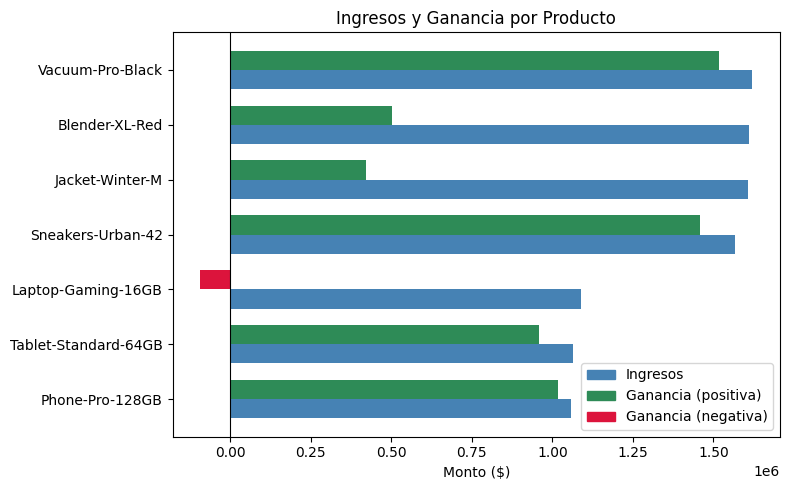

In [141]:
# Creo la variable con los valores necesarios de ventas por producto (ventas, costo y ganancia)
ventas_producto = ventas.groupby('nombre_producto').agg(
    ingresos = ('monto_total', 'sum'),
    costos = ('costo_total', 'sum')
).reset_index()
ventas_producto['ganancia'] = ventas_producto['ingresos'] - ventas_producto['costos']
ventas_producto = ventas_producto.sort_values('ingresos', ascending=True)

y = np.arange(len(ventas_producto)) # Defino posiciones numéricas del eje Y, 1 por producto
height = 0.35 # Alto de columnas

# Configuro los colores de acuerdo a la ganancia
colores_ganancia = ['seagreen' if v >= 0 else 'crimson' for v in ventas_producto['ganancia']]

# Creo la figura y grafico ingresos y ganancia por producto
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(y - height/2, ventas_producto['ingresos'], height, label='Ingresos', color='steelblue')
ax.barh(y + height/2, ventas_producto['ganancia'], height, color=colores_ganancia)

# Configuro etiquetas, título y línea de referencia en cero
ax.set_yticks(y)
ax.set_yticklabels(ventas_producto['nombre_producto'])
ax.set_xlabel('Monto ($)')
ax.set_title('Ingresos y Ganancia por Producto')
ax.axvline(0, color='black', linewidth=0.8)

# Leyenda manual, porque "Ganancia" no tiene un solo color fijo
handles = [
    plt.Rectangle((0,0),1,1,color='steelblue'),
    plt.Rectangle((0,0),1,1,color='seagreen'),
    plt.Rectangle((0,0),1,1,color='crimson')
]
# Definición de la información dentro de la leyenda
ax.legend(handles, ['Ingresos', 'Ganancia (positiva)', 'Ganancia (negativa)'])

plt.tight_layout()
plt.show()

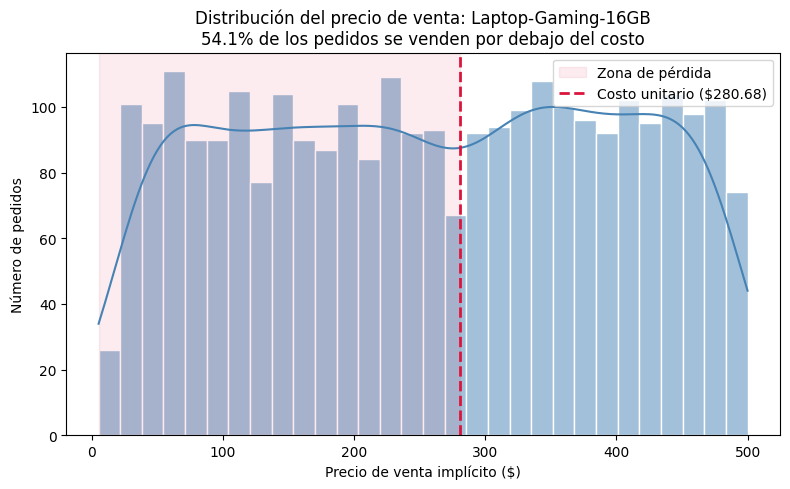

In [143]:
# Filtro Laptop-Gaming-16GB y calculo su precio de venta implícito para compararlo contra su costo
laptop = ventas[ventas['nombre_producto'] == 'Laptop-Gaming-16GB'].copy()
laptop['precio_unitario_implicito'] = laptop['monto_total'] / laptop['cantidad']

costo_laptop = laptop['costo_unitario'].iloc[0]
pct_perdida = (laptop['precio_unitario_implicito'] < costo_laptop).mean() * 100

# Creo la figura y el gráfico de distribución del precio de venta
fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(laptop['precio_unitario_implicito'], bins=30, kde=True,
             color='steelblue', edgecolor='white', ax=ax)

ax.axvspan(laptop['precio_unitario_implicito'].min(), costo_laptop, color='crimson', alpha=0.08, label='Zona de pérdida')
ax.axvline(costo_laptop, color='crimson', linewidth=2, linestyle='--', label=f'Costo unitario (${costo_laptop:,.2f})')

ax.set_title(f'Distribución del precio de venta: Laptop-Gaming-16GB\n{pct_perdida:.1f}% de los pedidos se venden por debajo del costo')
ax.set_xlabel('Precio de venta implícito ($)')
ax.set_ylabel('Número de pedidos')
ax.legend()

plt.tight_layout()
plt.show()

##### Interpretación

Con estas 3 gráficas representamos y confirmamos visualmente que el comportamiento entre los 3 países identificados (Argentina, Colombia y México) es prácticamente igual en ingresos, costos y rentabilidad (~29-30%). El segmento "Desconocido" muestra una rentabilidad aparentemente mucho mayor (61.3%), pero esto no es comparable: se debe a que esos 300 pedidos no tienen ningún gasto de marketing asociado en los datos, no a que ese mercado sea genuinamente más rentable. 

Finalmente, el histograma confirma que Laptop-Gaming-16GB tiene una severa pérdida en lugar de ganancia, debido a que el 54% de sus ventas se realizan con un precio inferior a su costo.

### Comportamiento de ventas

In [ ]:
# Función para obtener ticket promedio y cantidad de articulos promedio
def metricas(df, col, valor_global='Total Global'):
    metricas_ordenes = df.groupby(col).agg(
        ticket_promedio = ('monto_total', 'mean'),
        cantidad_promedio_articulo = ('cantidad', 'mean')
    ).reset_index()

    metricas_global = pd.DataFrame([{col : 'Total Global',
                                    'ticket_promedio':df['monto_total'].mean(),
                                    'cantidad_promedio_articulo':df['cantidad'].mean()}])

    metricas = pd.concat([metricas_ordenes, metricas_global], ignore_index = True)

    return metricas


In [ ]:
metricas_pais = metricas(ventas, 'pais')
metricas_disp = metricas(ventas, 'dispositivo')

In [ ]:
metricas_pais

,pais,ticket_promedio,cantidad_promedio_articulo
0,Argentina,389.12,1.51
1,Colombia,382.93,1.50
2,Desconocido,377.12,1.49
3,Mexico,386.10,1.51
4,Total Global,385.91,1.51


In [ ]:
metricas_disp

,dispositivo,ticket_promedio,cantidad_promedio_articulo
0,desktop,387.10,1.51
1,mobile,384.68,1.50
2,Total Global,385.91,1.51


In [ ]:
print('Descuento promedio por país')
ventas.groupby('pais')['monto_descuento'].mean()

Descuento promedio por país


pais
Argentina     4.41
Colombia      4.49
Desconocido   4.48
Mexico        4.61
Name: monto_descuento, dtype: float64

In [ ]:
print('Descuento pormedio por dispositivo')
ventas.groupby('dispositivo')['monto_descuento'].mean()

Descuento pormedio por dispositivo


dispositivo
desktop   4.55
mobile    4.45
Name: monto_descuento, dtype: float64

Los Tickets promedio están prácticamente iguales (diferencia de $10 - $20 prox.) con una cantidad promedio comprensible para el giro del negocio, los clientes dificilmente adquirirían más de 2 unidades de artículos.

De igual manera, comparando con dispositivos y por monto de descuento, el ticket y la cantidad de articulos promedio respeta el mismo rango que los paises, por lo que es uniforme la distribución de la venta entre estas variables

In [ ]:
# Producto más vendido por país y global
productos_vendidos = ventas.groupby(['pais', 'nombre_producto'])['cantidad'].sum().reset_index()
top_productos = productos_vendidos.sort_values(['pais', 'cantidad'], ascending=[True, False]).groupby('pais').first().reset_index()

top_global = ventas.groupby('nombre_producto')['cantidad'].sum().reset_index().sort_values('cantidad', ascending=False).head(1)
top_global['pais'] = 'Total Global'

top_productos = pd.concat([top_productos, top_global], ignore_index=True)

In [ ]:
top_productos

,pais,nombre_producto,cantidad
0,Argentina,Sneakers-Urban-42,"2,053.00"
1,Colombia,Jacket-Winter-M,"2,114.00"
2,Desconocido,Blender-XL-Red,91.00
3,Mexico,Blender-XL-Red,"2,172.00"
4,Total Global,Vacuum-Pro-Black,"6,284.00"


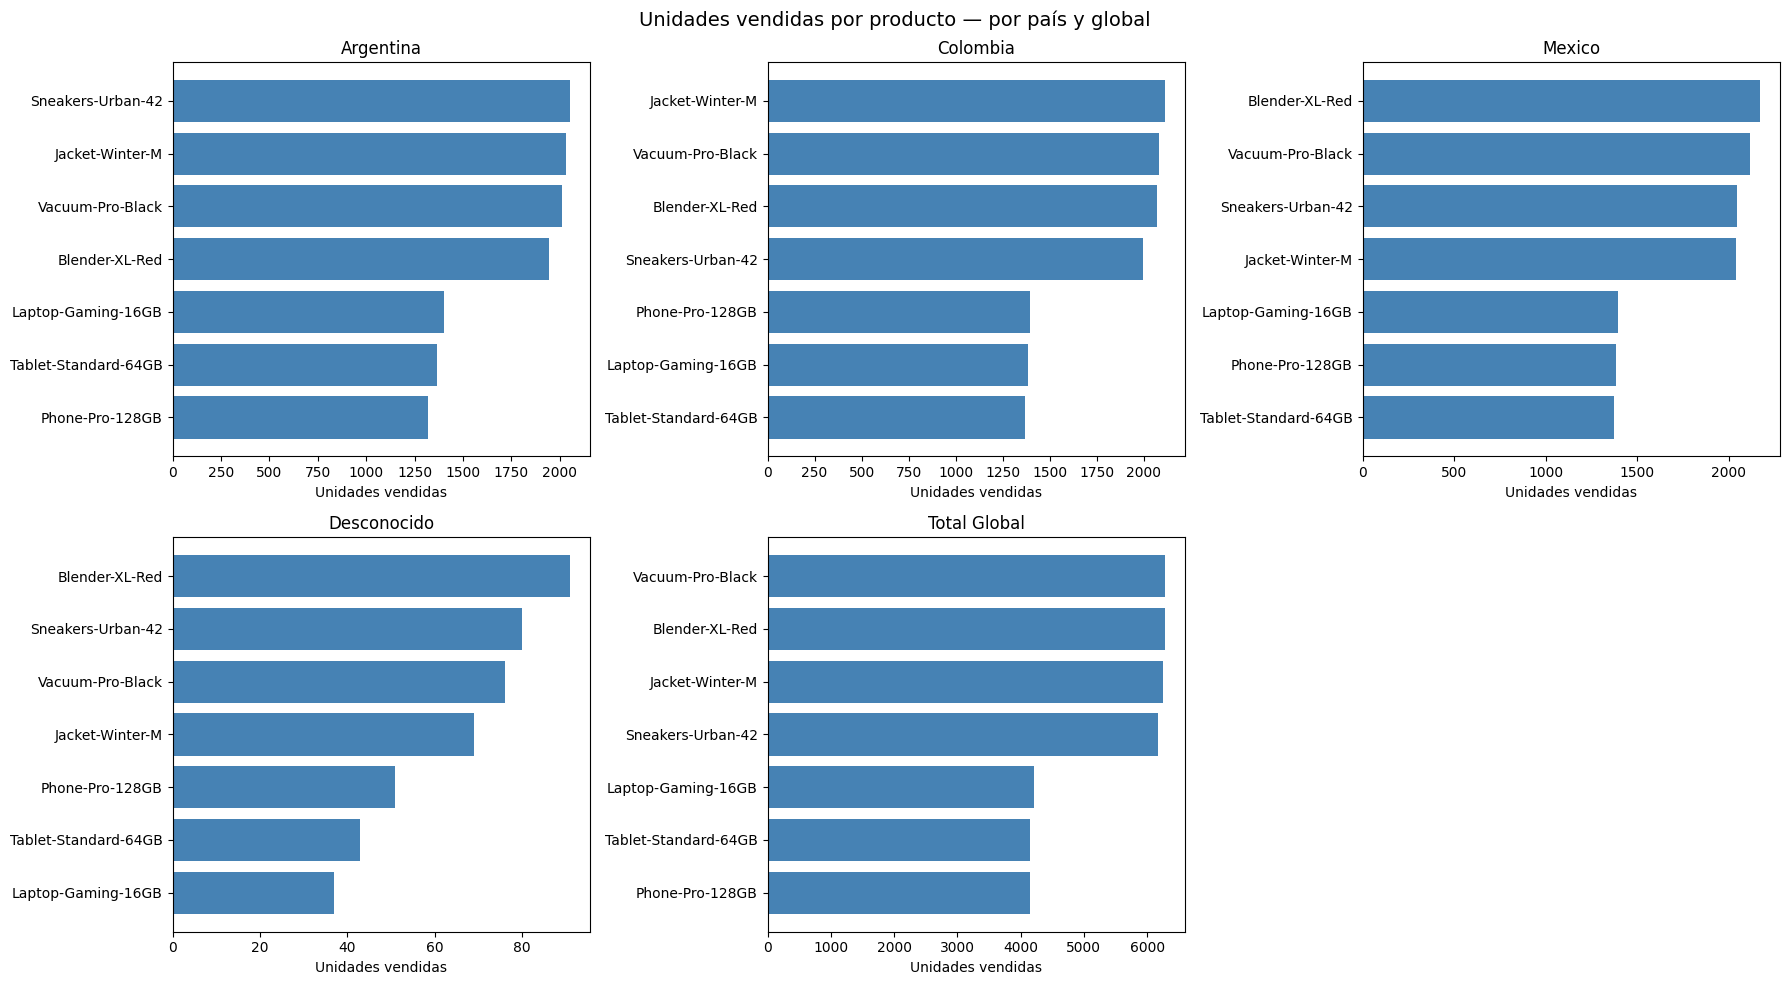

In [144]:
# Cantidad vendida por producto a nivel global (para completar lo que ya tienes por país)
productos_global = ventas.groupby('nombre_producto')['cantidad'].sum().reset_index()
productos_global['pais'] = 'Total Global'

# Uno tu 'productos_vendidos' (por país) con el global, para iterar en un solo bucle
productos_todos = pd.concat([productos_vendidos, productos_global], ignore_index=True)

paises_a_graficar = ['Argentina', 'Colombia', 'Mexico', 'Desconocido', 'Total Global']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, pais in enumerate(paises_a_graficar):
    data = productos_todos[productos_todos['pais'] == pais].sort_values('cantidad', ascending=True)
    axes[i].barh(data['nombre_producto'], data['cantidad'], color='steelblue')
    axes[i].set_title(pais)
    axes[i].set_xlabel('Unidades vendidas')

axes[-1].axis('off')  # el 6to panel queda vacío (solo 5 gráficos)

plt.suptitle('Unidades vendidas por producto — por país y global', fontsize=14)
plt.tight_layout()
plt.show()

Cada país tiene su artículo top con las cantidades muy similares, sin embargo, la diferencia entre los 4 productos más vendidos es marginal (~1.8%), por lo que el liderazgo de Vacuum-Pro-Black a nivel global refleja consistencia entre países más que una preferencia dominante

In [ ]:
# Gastos de marketing por país y global
gasto_canal = marketing.groupby(['pais', 'canal'])['gasto'].sum().reset_index()
matriz_marketing = gasto_canal.pivot(index='pais', columns='canal', values='gasto').fillna(0).reset_index()

global_mkt = marketing.groupby('canal')['gasto'].sum().to_frame().T
global_mkt['pais']= 'Total Global'
matriz_marketing = pd.concat([matriz_marketing, global_mkt], ignore_index=True)

matriz_marketing['total_pais'] = matriz_marketing[['organic', 'paid_search', 'social']].sum(axis=1)

pd.options.display.float_format = '{:,.2f}'.format

In [ ]:
matriz_marketing

canal,pais,organic,paid_search,social,total_pais
0,Argentina,"319,196.99","297,321.98","331,175.63","947,694.60"
1,Colombia,"323,222.51","298,901.96","313,528.95","935,653.42"
2,Mexico,"330,231.46","326,150.26","332,113.79","988,495.51"
3,Total Global,"972,650.96","922,374.20","976,818.37","2,871,843.53"


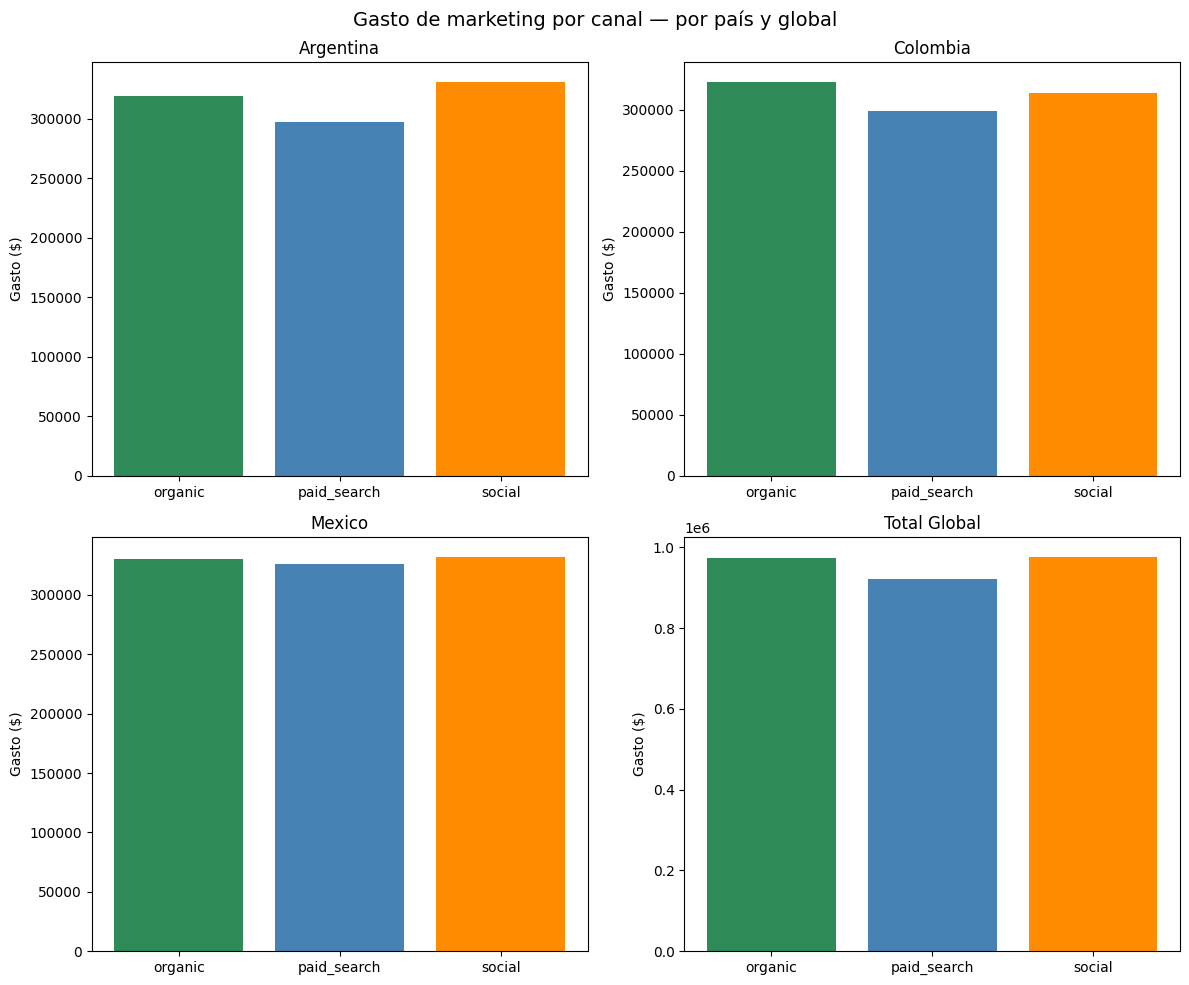

In [145]:
paises_mkt = matriz_marketing['pais'].tolist()  # Argentina, Colombia, Mexico, Total Global (4, sin Desconocido)
canales = ['organic', 'paid_search', 'social']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, pais in enumerate(paises_mkt):
    fila = matriz_marketing[matriz_marketing['pais'] == pais][canales].iloc[0]
    axes[i].bar(canales, fila.values, color=['seagreen', 'steelblue', 'darkorange'])
    axes[i].set_title(pais)
    axes[i].set_ylabel('Gasto ($)')

plt.suptitle('Gasto de marketing por canal — por país y global', fontsize=14)
plt.tight_layout()
plt.show()

La inversión en marketing es homogénea entre países ($900k - 990k c/u), lo cual es 
consistente con la rentabilidad también uniforme que se observó entre Argentina, 
Colombia y México (29.3% - 30.4%). No hay evidencia de que el presupuesto publicitario 
esté generando ventajas o desventajas competitivas entre mercados.

Como único matiz, México muestra una mezcla de canal ligeramente distinta: paid_search 
representa 32.99% de su presupuesto total, frente a 31.37% en Argentina y 31.95% en 
Colombia (1.6 puntos porcentuales por encima). Sin embargo, esta variación es menor y no se refleja en 
ningún cambio de rentabilidad, por lo que se interpreta como una diferencia operativa 
normal entre mercados y no como un factor relevante para el análisis.